In [ ]:
# Cynthia Model

import numpy as np
import pandas as pd
from scipy.optimize import linprog

# ----------------------------------------------------
# 1. LOAD INPUTS (LINEAR MODEL)
# ----------------------------------------------------
# mu_annual.npy   : expected annual returns, shape (n,)
# sigma_annual.npy: annualized SD per ticker, shape (n,)
# corr_score.npy  : per-ticker "sector correlation score", shape (n,)
# tickers.csv     : tickers in same order as above, one column
mu = np.load("mu_annual.npy")              # (n,)
sigma = np.load("sigma_annual.npy")        # (n,)
corr_score = np.load("corr_score.npy")     # (n,)
tickers = pd.read_csv("tickers.csv", header=None)[0].tolist()

# FIX: drop the index row if it exists
if tickers[0] == "0" or tickers[0] == 0:
    tickers = tickers[1:]

n = len(mu)
assert sigma.shape == (n,)
assert corr_score.shape == (n,)

# ----------------------------------------------------
# 2. OPTIMIZER: MAX RETURN, LINEAR RISK + CORR HEURISTIC
# ----------------------------------------------------
def max_return_low_corr_linear(mu, sigma, corr_score,
                               max_risk, max_corr_score,
                               max_weight=0.75):
    """
    Linear heuristic model:

        Maximize    w^T mu
        Subject to:
            w^T sigma      <= max_risk        (linear risk proxy)
            w^T corr_score <= max_corr_score  (linear sector-corr proxy)
            sum(w) = 1
            0 <= w_i <= max_weight

    NOTE: This is a heuristic, NOT true Markowitz risk.
    """

    n = len(mu)

    # linprog minimizes, so we minimize -mu^T w to maximize mu^T w
    c = -mu

    # Two linear inequality constraints: A_ub w <= b_ub
    # Row 0: sigma^T w <= max_risk
    # Row 1: corr_score^T w <= max_corr_score
    A_ub = np.vstack([sigma, corr_score])
    b_ub = np.array([max_risk, max_corr_score], dtype=float)

    # Equality constraint: sum(w) = 1
    A_eq = np.ones((1, n))
    b_eq = np.array([1.0])

    # Bounds: 0 <= w_i <= max_weight
    bounds = [(0.0, max_weight)] * n

    result = linprog(
        c=c,
        A_ub=A_ub,
        b_ub=b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )

    if not result.success:
        raise RuntimeError(f"Linear optimization failed: {result.message}")

    w = result.x

    port_return = float(np.dot(w, mu))
    port_risk_linear = float(np.dot(w, sigma))
    port_corr_linear = float(np.dot(w, corr_score))

    return w, port_return, port_risk_linear, port_corr_linear

# ----------------------------------------------------
# 3. RISK + CORR LIMITS (HEURISTIC SCALE)
# ----------------------------------------------------
risk_limits_linear = {
    "Aggressive_LC":    0.45,   # interpret as max linear "risk score"
    "Balanced_LC":      0.25,
    "Conservative_LC":  0.18,
}

corr_limits_linear = {
    "Aggressive_LC":    0.55,   # max linear correlation "score"
    "Balanced_LC":      0.45,
    "Conservative_LC":  0.35,
}

# ----------------------------------------------------
# 4. RUN LINEAR MODEL FOR EACH PROFILE
# ----------------------------------------------------
for profile in risk_limits_linear:
    max_risk = risk_limits_linear[profile]
    max_corr = corr_limits_linear[profile]

    w, ret, risk_lin, corr_lin = max_return_low_corr_linear(
        mu,
        sigma,
        corr_score,
        max_risk=max_risk,
        max_corr_score=max_corr,
        max_weight=0.75
    )

    df = pd.DataFrame({
        "Ticker": tickers,
        "Weight": w
    }).sort_values("Weight", ascending=False)

    print("\n=========================================")
    print(f"LINEAR MODEL – {profile}")
    print("=========================================")
    print(f"Return (mu^T w):         {ret: .2%}")
    print(f"Linear Risk (w·sigma):   {risk_lin: .4f} (limit {max_risk})")
    print(f"Linear Corr (w·score):   {corr_lin: .4f} (limit {max_corr})\n")
    print(df[df["Weight"] > 0.001])

    df.to_csv(f"{profile}_linear_lowcorr_portfolio.csv", index=False)

print("\n[Linear model] Portfolios saved as CSV files.")



LINEAR MODEL – Aggressive_LC
Return (mu^T w):          83.14%
Linear Risk (w·sigma):    0.4500 (limit 0.45)
Linear Corr (w·score):    0.4738 (limit 0.55)

   Ticker    Weight
22   NVDA  0.689542
10     GE  0.310458

LINEAR MODEL – Balanced_LC
Return (mu^T w):          44.57%
Linear Risk (w·sigma):    0.2500 (limit 0.25)
Linear Corr (w·score):    0.4500 (limit 0.45)

   Ticker    Weight
30   WELL  0.506673
10     GE  0.387932
14    JNJ  0.105394

LINEAR MODEL – Conservative_LC
Return (mu^T w):          12.79%
Linear Risk (w·sigma):    0.1800 (limit 0.18)
Linear Corr (w·score):    0.3500 (limit 0.35)

   Ticker    Weight
14    JNJ  0.750000
1    ABBV  0.138761
27     SO  0.109589
31    WMT  0.001650

[Linear model] Portfolios saved as CSV files.


In [41]:
# Ensure date is datetime
sp500_subset2 = pd.read_csv("sp500_subset2.csv")

sp500_subset2["Date"] = pd.to_datetime(sp500_subset2["Date"])

# Pivot into wide daily log returns matrix
returns_wide = sp500_subset2.pivot(
    index="Date",
    columns="Symbol",
    values="LogReturn"
).sort_index()

# Drop dates where all tickers are NaN
returns_wide = returns_wide.dropna(how="all")


In [42]:
cov_daily = returns_wide.cov()   # shape (n, n)
cov_annual = cov_daily * 252
np.save("cov_annual.npy", cov_annual.values)

# Save tickers in correct order
pd.Series(returns_wide.columns).to_csv("tickers.csv", index=False, header=False)


In [ ]:
## UPDATED MARKOWITZ MODEL (PORTFOLIO RISK CAL UPDATED)

import numpy as np
import pandas as pd
import cvxpy as cp

# ----------------------------------------------------
# 1. LOAD INPUTS (QUADRATIC / MARKOWITZ MODEL)
# ----------------------------------------------------

mu = np.load("mu_annual.npy")        # (n,)
cov = np.load("cov_annual.npy")      # (n, n)
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# FIX: drop the index row if it exists
if tickers[0].strip() == "0":
    tickers = tickers[1:]

n = len(mu)

assert cov.shape == (n, n), f"Expected {n}x{n} covariance, got {cov.shape}"

# Symmetrize & regularize covariance for numerical stability
cov = 0.5 * (cov + cov.T)
eps = 1e-8
cov = cov + eps * np.eye(n)

# ----------------------------------------------------
# 2. BUILD CORRELATION MATRIX
# ----------------------------------------------------
sigma_vec = np.sqrt(np.diag(cov))        

with np.errstate(divide="ignore", invalid="ignore"):
    denom = np.outer(sigma_vec, sigma_vec)
    corr_mat = cov / denom
    corr_mat[~np.isfinite(corr_mat)] = 0.0

np.fill_diagonal(corr_mat, 1.0)
corr_mat = 0.5 * (corr_mat + corr_mat.T)
corr_mat = corr_mat + eps * np.eye(n)

# ----------------------------------------------------
# 3. OPTIMIZER
# ----------------------------------------------------
def max_return_low_corr_markowitz(mu, cov, corr_mat,
                                  max_vol,
                                  max_corr_score,
                                  max_weight=1.0): 

    n = len(mu)
    w = cp.Variable(n)

    port_var = cp.quad_form(w, cov)
    corr_score_expr = cp.quad_form(w, corr_mat)

    objective = cp.Maximize(mu @ w)

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight,
        port_var <= max_vol**2,
        corr_score_expr <= max_corr_score,
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    if (w.value is None) or (prob.status not in ["optimal", "optimal_inaccurate"]):
        raise RuntimeError(f"Quadratic optimization failed: {prob.status}")

    w_opt = np.array(w.value).flatten()
    port_return = float(mu @ w_opt)
    port_vol = float(np.sqrt(w_opt @ cov @ w_opt))
    port_corr = float(w_opt @ corr_mat @ w_opt)

    return w_opt, port_return, port_vol, port_corr

# ----------------------------------------------------
# 4. LIMITS
# ----------------------------------------------------
risk_limits_quad = {
    "Aggressive_LC":    0.45,
    "Balanced_LC":      0.25,
    "Conservative_LC":  0.18,
}

corr_limits_quad = {
    "Aggressive_LC":    0.55,
    "Balanced_LC":      0.45,
    "Conservative_LC":  0.35,
}

# ----------------------------------------------------
# 5. RUN OPTIMIZER
# ----------------------------------------------------
results = {}

for profile in risk_limits_quad:
    max_vol = risk_limits_quad[profile]
    max_corr_score = corr_limits_quad[profile]

    w, ret, vol, corr_q = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=max_vol,
        max_corr_score=max_corr_score,
        max_weight=0.75
    )

    df = pd.DataFrame({
        "Ticker": tickers,
        "Weight": w
    }).sort_values("Weight", ascending=False)

    print("\n=========================================")
    print(f"MARKOWITZ MODEL – {profile}")
    print("=========================================")
    print(f"Return (mu^T w):          {ret: .2%}")
    print(f"Volatility (sqrt wΣw):    {vol: .2%} (limit {max_vol: .2%})")
    print(f"CorrScore (w^T C w):      {corr_q: .4f} (limit {max_corr_score: .4f})\n")
    print(df[df["Weight"] > 0.001])

    results[profile] = {
        "w": w,
        "ret": ret,
        "vol": vol,
        "corr": corr_q,
    }



MARKOWITZ MODEL – Aggressive_LC
Return (mu^T w):           78.06%
Volatility (sqrt wΣw):     36.04% (limit  45.00%)
CorrScore (w^T C w):       0.5500 (limit  0.5500)

   Ticker    Weight
22   NVDA  0.544345
6     CEG  0.215254
17    LLY  0.108655
10     GE  0.067003
30   WELL  0.064743

MARKOWITZ MODEL – Balanced_LC
Return (mu^T w):           64.17%
Volatility (sqrt wΣw):     25.00% (limit  25.00%)
CorrScore (w^T C w):       0.4265 (limit  0.4500)

   Ticker    Weight
10     GE  0.294013
22   NVDA  0.267796
30   WELL  0.174920
17    LLY  0.171985
6     CEG  0.091287

MARKOWITZ MODEL – Conservative_LC
Return (mu^T w):           49.52%
Volatility (sqrt wΣw):     18.00% (limit  18.00%)
CorrScore (w^T C w):       0.3433 (limit  0.3500)

   Ticker    Weight
30   WELL  0.228710
10     GE  0.189068
31    WMT  0.188506
17    LLY  0.145404
22   NVDA  0.129096
1    ABBV  0.071708
6     CEG  0.047508


In [55]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # Load correlation matrix and tickers
# cov = np.load("cov_annual.npy")
# tickers = pd.read_csv("tickers.csv", header=None)[0].tolist()

# # Convert covariance → correlation matrix
# sigma = np.sqrt(np.diag(cov))
# corr_mat = cov / np.outer(sigma, sigma)

# plt.figure(figsize=(12,10))
# plt.imshow(corr_mat, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label="Correlation")
# plt.xticks(range(len(tickers)), tickers, rotation=90)
# plt.yticks(range(len(tickers)), tickers)
# plt.title("Asset Correlation Matrix")
# plt.tight_layout()
# plt.show()


In [54]:
# import matplotlib.pyplot as plt

# profiles = list(results.keys())
# rets  = [results[p]["ret"]  for p in profiles]
# vols  = [results[p]["vol"]  for p in profiles]
# corrs = [results[p]["corr"] for p in profiles]

# # ---- Scatter Plot ----
# plt.figure(figsize=(8,6))
# plt.scatter(vols, rets, s=300, c=corrs, cmap="coolwarm", edgecolors='black')

# for i, label in enumerate(profiles):
#     plt.text(vols[i] + 0.002, rets[i] + 0.005, label, fontsize=12)

# cbar = plt.colorbar()
# cbar.set_label("CorrScore (wᵀ C w)")

# plt.xlabel("Volatility (σ)")
# plt.ylabel("Expected Return")
# plt.title("Risk–Return–Correlation Tradeoff")
# plt.grid(True)
# plt.show()


In [56]:
# Markowitz Model 2: 1 STOCK PER SECTOR CONSTRAINT

import numpy as np
import pandas as pd
import cvxpy as cp

# ====================================================
# 0. PARAMETERS (easy to tune here)
# ====================================================
MAX_WEIGHT_PER_STOCK = 1        # cap on individual stock weight
MIN_SECTOR_WEIGHT    = 0.01        # ensures ≥1 stock per sector (1% minimum)
EPSILON              = 1e-8        # numerical stability

RISK_LIMITS = {
    "Aggressive_LC":    0.45,
    "Balanced_LC":      0.25,
    "Conservative_LC":  0.18,
}

CORR_LIMITS = {
    "Aggressive_LC":    0.55,
    "Balanced_LC":      0.45,
    "Conservative_LC":  0.35,
}

# ====================================================
# 1. LOAD DATA
# ====================================================
mu = np.load("mu_annual.npy")
cov = np.load("cov_annual.npy")
tickers = pd.read_csv("tickers.csv", header=None)[0].astype(str).tolist()

# Remove accidental index row if present
if tickers[0].strip() == "0":
    tickers = tickers[1:]

n = len(mu)
assert cov.shape == (n, n), f"Expected {n}x{n}, got {cov.shape}"

# Load sector map from sp500_sectors.csv

sector_df = pd.read_csv("../data/sp500_sectors.csv")
sector_map = sector_df.set_index("Symbol")["Sector"]

# Align sectors to tickers
sectors = [sector_map[t] for t in tickers]
unique_sectors = sorted(set(sectors))

# ====================================================
# 2. BUILD CORRELATION MATRIX
# ====================================================
cov = 0.5 * (cov + cov.T)            # symmetrize
cov += EPSILON * np.eye(n)           # regularize

sigma_vec = np.sqrt(np.diag(cov))
denom = np.outer(sigma_vec, sigma_vec)

with np.errstate(divide="ignore", invalid="ignore"):
    corr_mat = cov / denom
    corr_mat[~np.isfinite(corr_mat)] = 0.0

np.fill_diagonal(corr_mat, 1.0)
corr_mat = 0.5 * (corr_mat + corr_mat.T)
corr_mat += EPSILON * np.eye(n)

# ====================================================
# 3. OPTIMIZER FUNCTION
# ====================================================
def solve_portfolio(mu, cov, corr_mat, max_vol, max_corr, max_weight):
    w = cp.Variable(n)

    # Objective: maximize expected return
    objective = cp.Maximize(mu @ w)

    # Main constraints
    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w <= max_weight,
        cp.quad_form(w, cov) <= max_vol**2,
        cp.quad_form(w, corr_mat) <= max_corr,
    ]

    # Sector constraint: ensure ≥1 stock per sector
    for sector in unique_sectors:
        idx = [i for i, s in enumerate(sectors) if s == sector]
        constraints.append(cp.sum(w[idx]) >= MIN_SECTOR_WEIGHT)

    # Solve model
    prob = cp.Problem(objective, constraints)
    prob.solve()

    if w.value is None:
        raise RuntimeError(f"Optimization failed: {prob.status}")

    w_opt = np.array(w.value).flatten()
    ret = float(mu @ w_opt)
    vol = float(np.sqrt(w_opt @ cov @ w_opt))
    corr_score = float(w_opt @ corr_mat @ w_opt)

    return w_opt, ret, vol, corr_score

# ====================================================
# 4. RUN OPPTIMIZER FOR EACH PROFILE
# ====================================================
results = {}

for profile in RISK_LIMITS:
    max_vol  = RISK_LIMITS[profile]
    max_corr = CORR_LIMITS[profile]

    w, ret, vol, corr = solve_portfolio(
        mu, cov, corr_mat,
        max_vol=max_vol,
        max_corr=max_corr,
        max_weight=MAX_WEIGHT_PER_STOCK
    )

    df = pd.DataFrame({"Ticker": tickers, "Weight": w})
    df = df[df["Weight"] > 0.001].sort_values("Weight", ascending=False)

    print("\n=========================================")
    print(f"MARKOWITZ MODEL – {profile}")
    print("=========================================")
    print(f"Return:     {ret: .2%}")
    print(f"Vol:        {vol: .2%} (limit {max_vol: .2%})")
    print(f"CorrScore:  {corr: .4f} (limit {max_corr: .4f})")
    print(df)

    results[profile] = {"w": w, "ret": ret, "vol": vol, "corr": corr}



MARKOWITZ MODEL – Aggressive_LC
Return:      77.00%
Vol:         36.30% (limit  45.00%)
CorrScore:   0.5500 (limit  0.5500)
   Ticker    Weight
22   NVDA  0.551864
6     CEG  0.206686
17    LLY  0.090949
10     GE  0.050982
30   WELL  0.039518
21    NEM  0.010000
31    WMT  0.010000
32    XOM  0.010000
28   TSLA  0.010000
15    JPM  0.010000
12  GOOGL  0.008252
18   META  0.001748

MARKOWITZ MODEL – Balanced_LC
Return:      63.21%
Vol:         25.00% (limit  25.00%)
CorrScore:   0.4150 (limit  0.4500)
   Ticker    Weight
10     GE  0.284688
22   NVDA  0.274891
17    LLY  0.157020
30   WELL  0.134074
6     CEG  0.089328
31    WMT  0.010000
21    NEM  0.010000
32    XOM  0.010000
15    JPM  0.010000
13     HD  0.010000
11   GOOG  0.010000

MARKOWITZ MODEL – Conservative_LC
Return:      49.05%
Vol:         18.00% (limit  18.00%)
CorrScore:   0.3359 (limit  0.3500)
   Ticker    Weight
30   WELL  0.218767
10     GE  0.185087
31    WMT  0.170083
17    LLY  0.146693
22   NVDA  0.128956
1    

In [95]:
## SENSITIVITY ANALYSIS ON RISK

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

vol_grid = np.linspace(0.10, 0.65, 10)  # vary risk from 10% to 50%
results_vol = []

for max_vol in vol_grid:
    try:
        w, ret, vol, corr = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=max_vol,
            max_corr_score=1.0,    # loose correlation limit
            max_weight=0.75
        )
        results_vol.append([max_vol, ret, vol, corr])
    except:
        results_vol.append([max_vol, np.nan, np.nan, np.nan])

df_vol = pd.DataFrame(results_vol, columns=["vol_limit", "ret", "vol", "corr"])
print("\n=== Risk Sensitivity ===")
print(df_vol)


=== Risk Sensitivity ===
   vol_limit       ret       vol      corr
0   0.100000       NaN       NaN       NaN
1   0.161111  0.440575  0.161111  0.317036
2   0.222222  0.591000  0.222222  0.392315
3   0.283333  0.692767  0.283333  0.473698
4   0.344444  0.773100  0.344444  0.589784
5   0.405556  0.839941  0.405556  0.692741
6   0.466667  0.881880  0.452459  0.781267
7   0.527778  0.881880  0.452459  0.781267
8   0.588889  0.881880  0.452459  0.781267
9   0.650000  0.881880  0.452459  0.781267


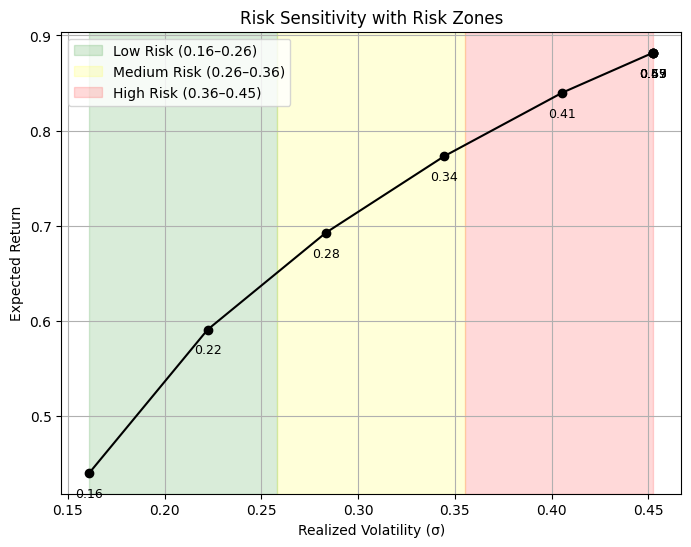

In [96]:
# Plot Risk Sensitivity with Risk Zones

# Extract realized vol values
valid = df_vol.dropna()

vmin = valid["vol"].min()
vmax = valid["vol"].max()

# Create 3 equal bins
bins = np.linspace(vmin, vmax, 4)   # [low, mid, high, max]
low, mid, high, maxv = bins

plt.figure(figsize=(8, 6))

# Shade zones
plt.axvspan(low, mid, color='green', alpha=0.15, label=f"Low Risk ({low:.2f}–{mid:.2f})")
plt.axvspan(mid, high, color='yellow', alpha=0.15, label=f"Medium Risk ({mid:.2f}–{high:.2f})")
plt.axvspan(high, maxv, color='red', alpha=0.15, label=f"High Risk ({high:.2f}–{maxv:.2f})")

# Plot the frontier
plt.plot(valid["vol"], valid["ret"], marker="o", color="black")

for _, row in valid.iterrows():
    plt.text(
        row["vol"], 
        row["ret"] - 0.015,     # shift downward
        f"{row['vol_limit']:.2f}",
        fontsize=9,
        ha='center',            # center horizontally
        va='top'                # align above the text baseline → text sits below point
    )


plt.xlabel("Realized Volatility (σ)")
plt.ylabel("Expected Return")
plt.title("Risk Sensitivity with Risk Zones")

plt.grid(True)
plt.legend(loc="upper left")
plt.show()


   corr_limit       ret       vol      corr
0         0.3  0.557074  0.231151  0.300000
1         0.4  0.672991  0.291238  0.400000
2         0.5  0.716061  0.300000  0.500000
3         0.6  0.716102  0.300000  0.505829
4         0.7  0.716102  0.300000  0.505828
5         0.8  0.716102  0.300000  0.505828
6         0.9  0.716102  0.300000  0.505829
7         1.0  0.716102  0.300000  0.505829
8         1.1  0.716102  0.300000  0.505830
9         1.2  0.716102  0.300000  0.505830


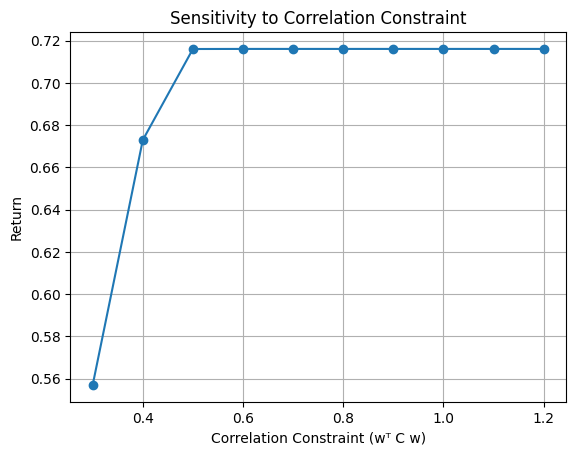

In [98]:
## SENSITIVITY ANALYSIS ON CORR LIMITS

corr_grid = np.linspace(0.30, 1.20, 10)
results_corr = []

for max_corr in corr_grid:
    try:
        w, ret, vol, corr = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=0.3,        # forced risk level
            max_corr_score=max_corr,
            max_weight=0.75
        )
        results_corr.append([max_corr, ret, vol, corr])
    except:
        results_corr.append([max_corr, np.nan, np.nan, np.nan])

df_corr = pd.DataFrame(results_corr,
                       columns=["corr_limit", "ret", "vol", "corr"])
print(df_corr)

plt.plot(df_corr["corr_limit"], df_corr["ret"], marker="o")
plt.xlabel("Correlation Constraint (wᵀ C w)")
plt.ylabel("Return")
plt.title("Sensitivity to Correlation Constraint")
plt.grid(True)
plt.show()



   max_weight       ret       vol      corr  num_assets
0        0.10  0.484812  0.219428  0.389294          10
1        0.15  0.562451  0.232417  0.400482           7
2        0.20  0.623049  0.244606  0.398024           5
3        0.30  0.641672  0.250000  0.426519           5
4        0.50  0.641672  0.250000  0.426520           5
5        0.75  0.641672  0.250000  0.426524           5


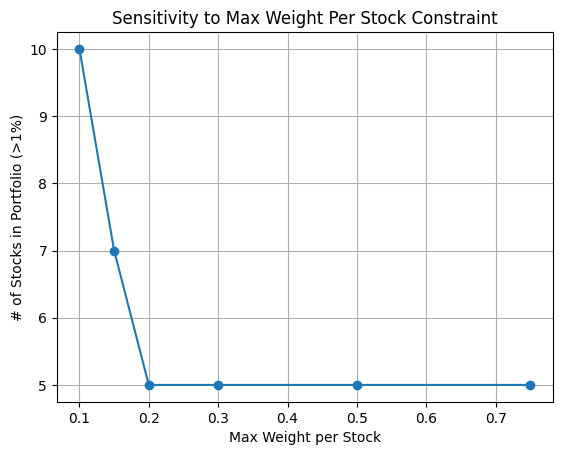

In [99]:
## SENSITIVTY ANALYSIS ON MAX WEIGHT PER STOCK

weight_grid = [0.10, 0.15, 0.20, 0.30, 0.50, 0.75]
results_weight = []

for mw in weight_grid:
    try:
        w, ret, vol, corr = max_return_low_corr_markowitz(
            mu, cov, corr_mat,
            max_vol=0.25,        # fixed Balanced risk
            max_corr_score=0.60, # fixed diversification level
            max_weight=mw
        )
        num_assets = (w > 0.01).sum()  # >1% exposure
        results_weight.append([mw, ret, vol, corr, num_assets])
    except:
        results_weight.append([mw, np.nan, np.nan, np.nan, np.nan])

df_weight = pd.DataFrame(results_weight,
                         columns=["max_weight", "ret", "vol", "corr", "num_assets"])
print(df_weight)

# Plot 

plt.plot(df_weight["max_weight"], df_weight["num_assets"], marker="o")
plt.xlabel("Max Weight per Stock")
plt.ylabel("# of Stocks in Portfolio (>1%)")
plt.title("Sensitivity to Max Weight Per Stock Constraint")
plt.grid(True)
plt.show()


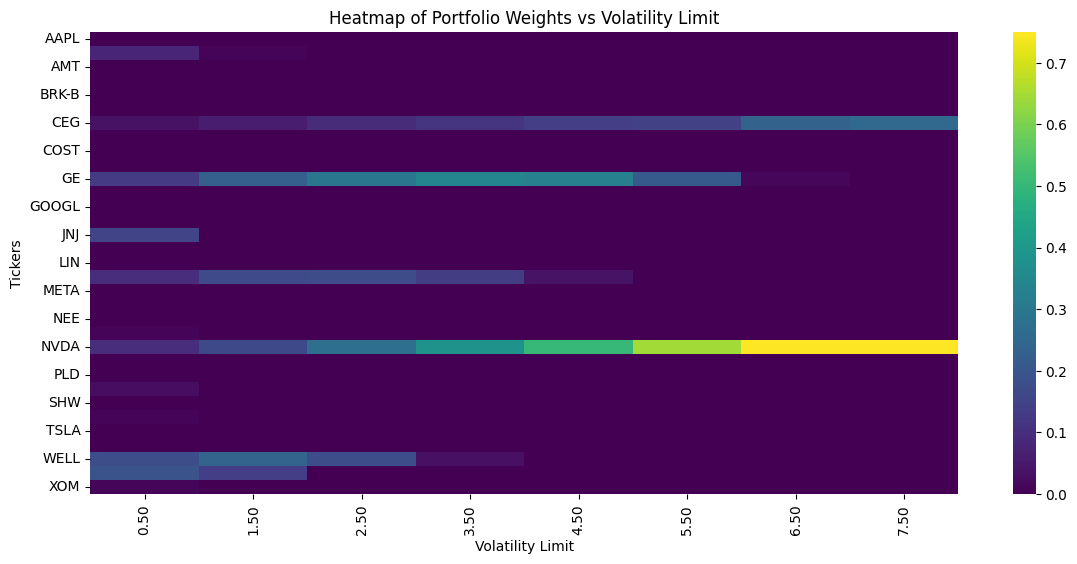

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

vol_grid = np.linspace(0.15, 0.50, 8)
weight_history = []

for max_vol in vol_grid:
    w, ret, vol, corr = max_return_low_corr_markowitz(
        mu, cov, corr_mat,
        max_vol=max_vol,
        max_corr_score=1.0,   # loose correlation constraint
        max_weight=0.75
    )
    weight_history.append(w)

weight_df = pd.DataFrame(weight_history, columns=tickers)
weight_df["vol_limit"] = vol_grid
weight_df = weight_df.set_index("vol_limit")

plt.figure(figsize=(14, 6))
sns.heatmap(weight_df.T, cmap="viridis", annot=False)
plt.title("Heatmap of Portfolio Weights vs Volatility Limit")
plt.xlabel("Volatility Limit")
plt.ylabel("Tickers")

# Format x-axis ticks to 2 decimals
xticks = plt.gca().get_xticks()
plt.gca().set_xticklabels([f"{x:.2f}" for x in xticks])

plt.show()
